In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from tqdm import tqdm, trange
import sctop as top

sns.set(context='talk', color_codes=True, palette='deep', style='whitegrid',
        rc={'mathtext.fontset': 'cm', 'xtick.direction': 'in','ytick.direction': 'in',
            'axes.linewidth': 1.5, 'figure.dpi':300, 'text.usetex':False}) #font_scale=0.3,

# 1. Load data
## Load gene expression profiles

In [4]:
mca, mca_metadata = top.load_basis('MC-KO', 50)

ciliated = mca['Lung Ciliated Cell WK6 KO22']
club = mca['Lung Club Cell WK6 KO22']
basal = mca['Lung Basal Cell WK6 KO22']

attractor_states = pd.concat([club, ciliated, basal], axis = 1)
attractor_states.columns = ['club', 'ciliated', 'basal']

N, P = attractor_states.shape

# Simulate decision-making classes with spatial interactions

In [4]:
from multicellular_simulations import *

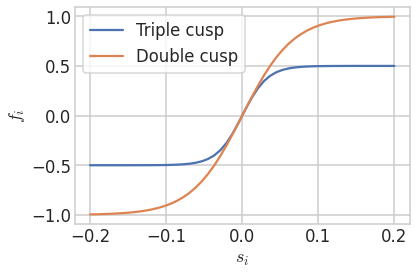

In [6]:
xs = np.linspace(-0.2, 0.2, 50)

# sigmoid temps: 5, 10, 30, 100, 1000
# std devs: 0, 1, 5, 10

plt.plot(xs, -sigmoid(xs, 0.5, 60), label='Triple cusp')
plt.plot(xs, -sigmoid(xs, 1, 30), label='Double cusp') 
plt.xlabel('$s_i$')
plt.ylabel('$f_i$')

plt.legend()
plt.show()

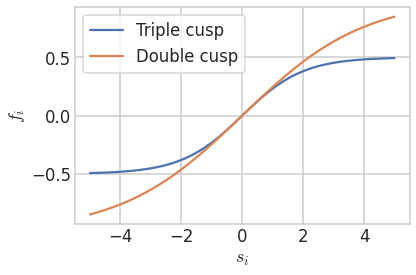

In [11]:
xs = np.linspace(-5, 5, 100)

# sigmoid temps: 5, 10, 30, 100, 1000
# std devs: 0, 1, 5, 10

plt.plot(xs, -sigmoid(xs, 0.5, 1), label='Triple cusp')
plt.plot(xs, -sigmoid(xs, 1, 0.5), label='Double cusp') 
plt.xlabel('$s_i$')
plt.ylabel('$f_i$')
plt.legend()

plt.savefig("/project/biophys/scTOP analyses/Hopfield landscape paper/figs/sigmoid.pdf", bbox_inches = "tight")
plt.show()

In [33]:
rng = np.random.default_rng()

total_time = 100

landscape_args = {'start_params': {'f': 0.1, 'k': 0.3, 'c': 2},
                  'attractor_coords': [[0, triple_cusp_coords['y0']], [triple_cusp_coords['x1'], triple_cusp_coords['y1']]],
                  'gradients': triple_cusp_grad,
                 }

dynamics_args = {'stored_states': attractor_states.T,
                 'rhos': [0.0, 10]
                }

# 1d chain of cells 
n_cells = 20
cell_list = []

for i in range(n_cells):
    # generate new initial coordinates for each 
    dynamics_args['initial_state'] =  attractor_states['basal'] #+ 5*rng.standard_normal(size=N)

    attractor_network = AttractorNetwork(dynamics_args, landscape_args)
    cell = Cell(attractor_network, i)
    
    gene_dict = {}
    for gene in notch_ligands:
        gene_dict[gene] = []
    gene_dict['f'] = []
    
    cell.position = i    
    cell.gene_record = gene_dict
    cell_list.append(cell)
    
# ===============================================================================================

t = 0
time_interval = 1 # in minutes        
for t in trange(total_time):
    for i, cell in enumerate(cell_list):

        if i == 0:
            neighbors = pd.DataFrame(cell_list[i + 1].attractor_network.state)
            neighbor_info = np.array([0.])
        elif i == len(cell_list) - 1:
            neighors = pd.DataFrame(cell_list[i - 1].attractor_network.state)
            neighbor_info = np.array([0.])
        else:
            neighbors = pd.concat([cell_list[i - 1].attractor_network.state,
                             cell_list[i + 1].attractor_network.state], axis=1)
            neighbor_info = np.array([0., 0.])
        
        for i, this_neighbor_info in enumerate(neighbor_info):
            magnetizations = (1/N)*cell.attractor_network.attractors.dot(neighbors.iloc[:, i].T)
            order_params = cell.attractor_network.inv_corr.dot(magnetizations.T)
            
            # order_params[0]: club, order_params[1]: ciliated
            # calculate if this cell is receiving a positive notch signal, i.e. push to become club
            neighbor_info[i] = order_params[1] - order_params[0]
                
        signaling_decision = np.max(neighbor_info)

        cell.attractor_network.params['f'] = - sigmoid(signaling_decision, 0.5, 1)
        
        cell.state_record += [(1/N)*cell.attractor_network.attractors.dot(cell.attractor_network.state.T)]

        for gene in notch_ligands:
            cell.gene_record[gene].append([cell.attractor_network.state.loc[gene]])
            
        cell.gene_record['f'].append(cell.attractor_network.params['f'])
        

        cell.attractor_network.update()
    
for cell in cell_list:
    magnetizations = pd.DataFrame(cell.state_record)
    order_params = cell.attractor_network.inv_corr.dot(magnetizations.T)
    cell.state_record = pd.DataFrame(order_params, index = magnetizations.columns).T
    cell.gene_record = pd.DataFrame(cell.gene_record)

# magnetizations = pd.DataFrame(magnetizations)
# order_params = cell.attractor_network.inv_corr.dot(magnetizations.T)
# output_df = pd.concat([pd.DataFrame(order_params, index = magnetizations.columns).T, magnetizations, pd.DataFrame(gene_dict)], axis=1)

100%|██████████| 100/100 [00:15<00:00,  6.41it/s]


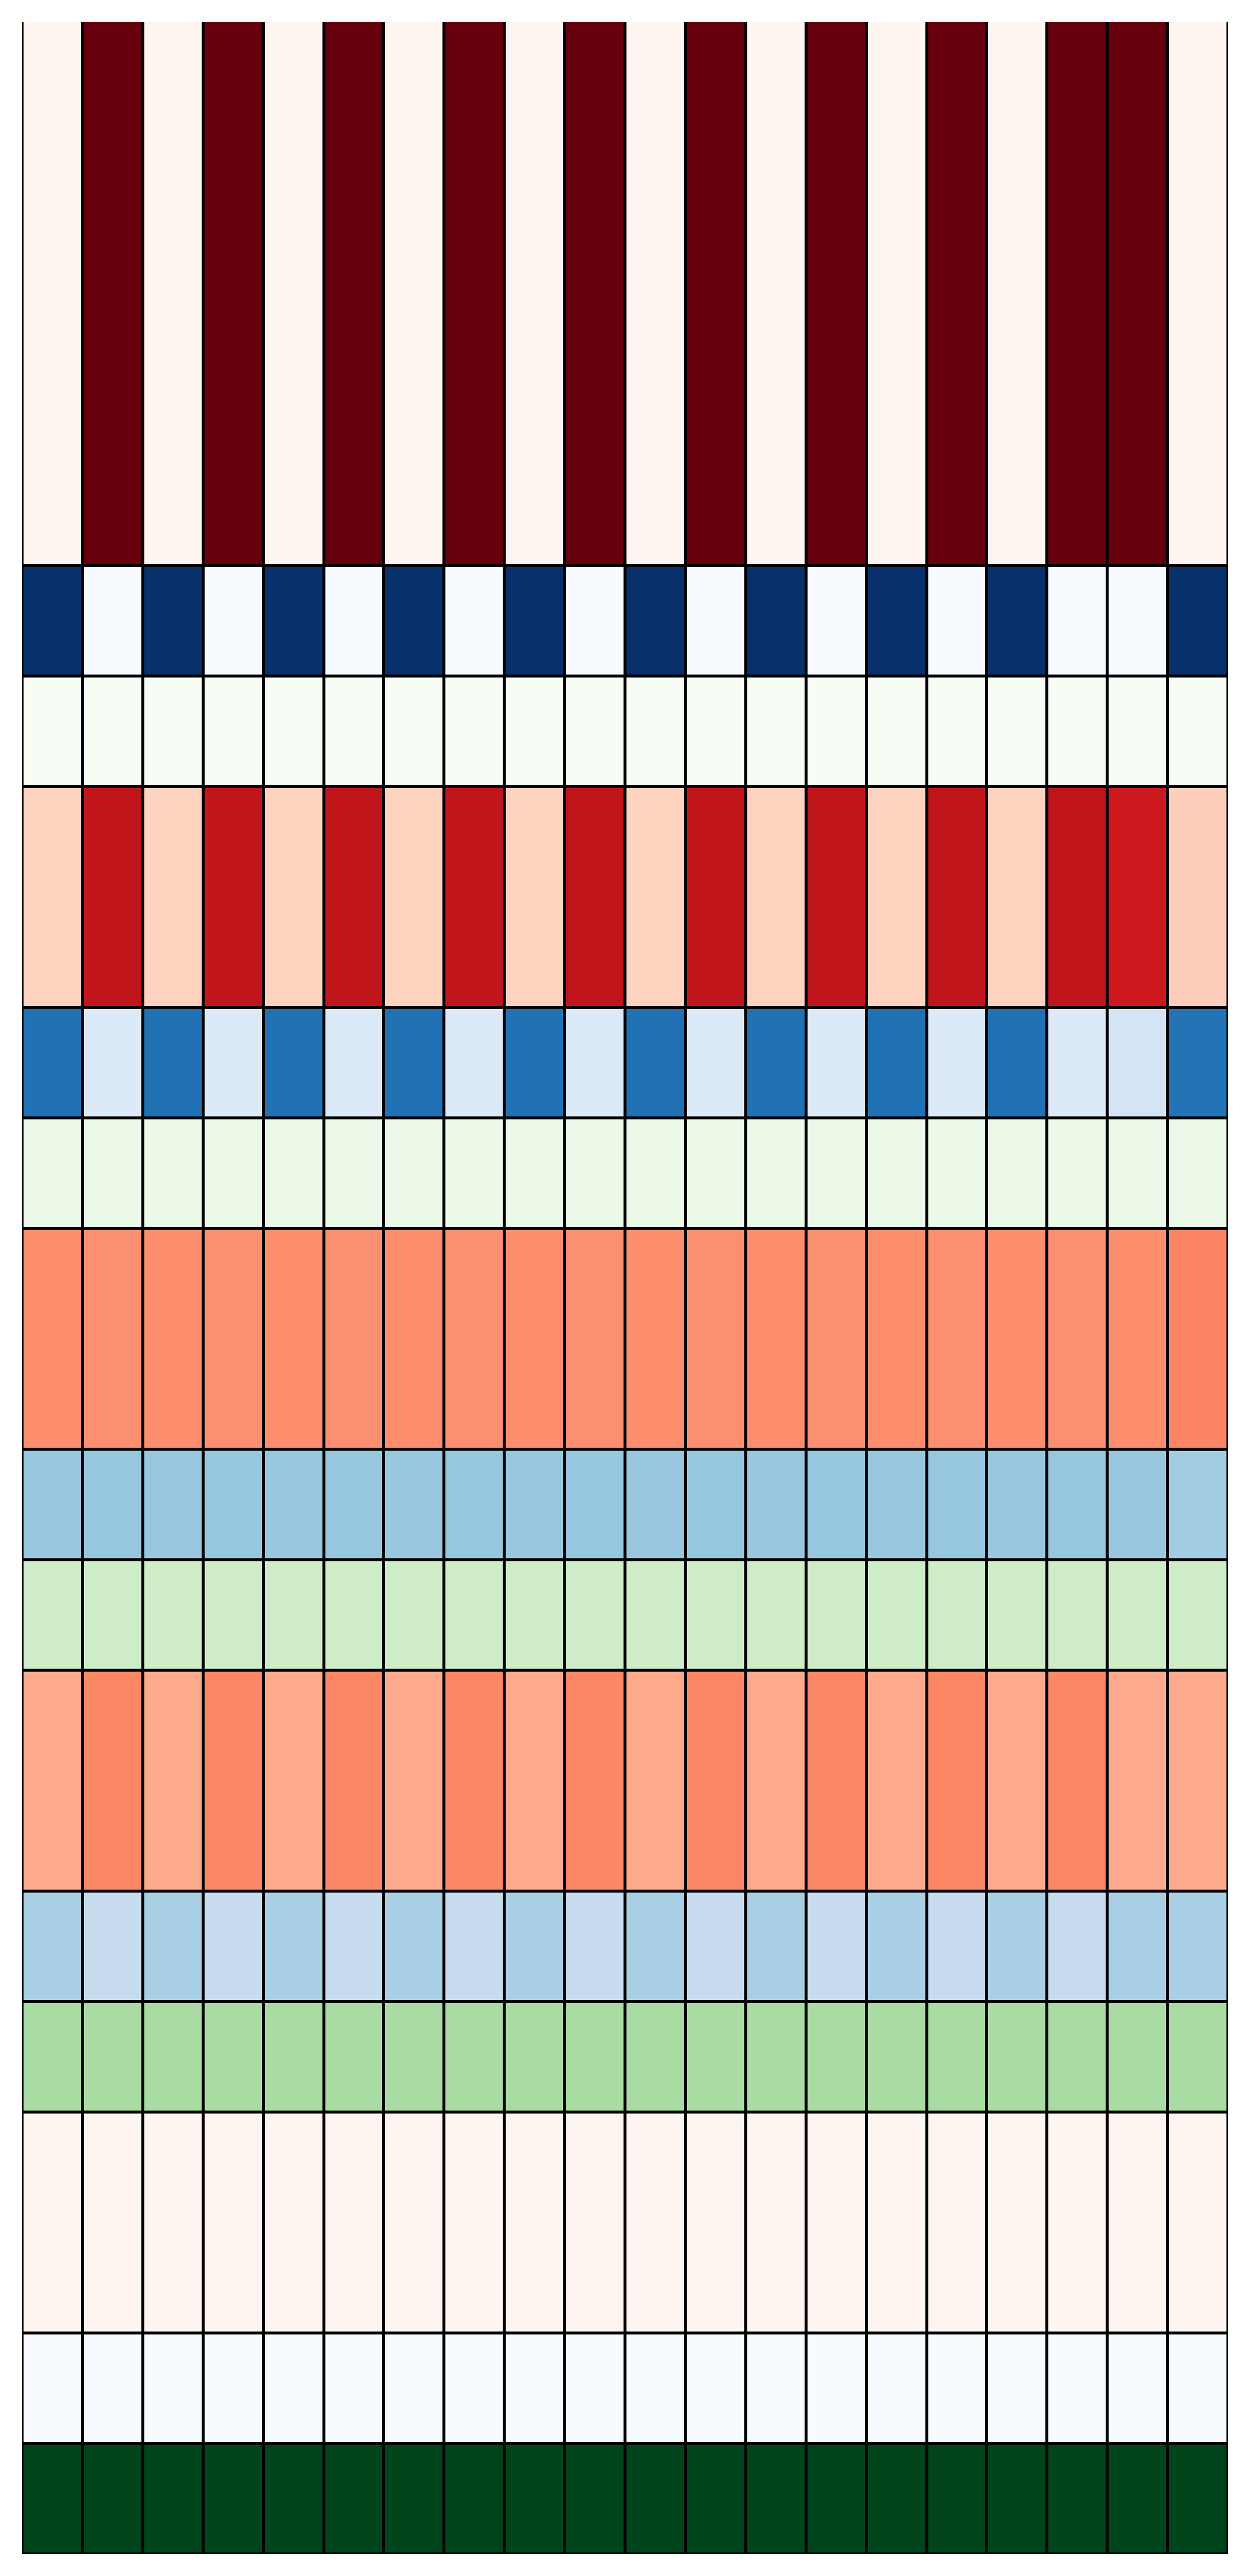

In [34]:
cmap_dict = {'ciliated': 'Blues',
             'club': 'Reds',
             'basal': 'Greens'
            }

time_points = [0, 10, 20, 30, 99]

width = 6
fig = plt.figure(figsize=(width, 2*width))

order_params_dict = {}

for subplot_index, cell_type in enumerate(attractor_states.columns):
    order_params = []

    for cell in cell_list:
        order_params.append(cell.state_record.loc[time_points, cell_type])

    order_params = pd.concat(order_params, axis=1)
    order_params.columns = ["Cell {}".format(number) for number in range(n_cells)]
    order_params_dict[cell_type] = order_params
    
#     ax = fig.add_subplot(1, 3, subplot_index+1)
#     ax.set_title(cell_type)

heatmap_position = 0
spacing = 150

for hmap_index, time_point in enumerate(time_points):
    for cell_type in attractor_states.columns[::-1]:
        sns.heatmap([order_params_dict[cell_type].iloc[hmap_index]], linewidths=0.5, linecolor='black', vmin=0, vmax=1, 
                cmap=cmap_dict[cell_type], cbar_kws={'label': cell_type}, offsets=(0, heatmap_position), cbar=None)
        heatmap_position += spacing
    heatmap_position += spacing
    
    
#     if subplot_index == 0:
#         ax.set_ylabel('Time')
# ax = plt.gca()
# for i in range(len(time_points)):
#     ax.axhline(i, color='white', lw=20)
plt.axis("off")


plt.tight_layout()
plt.savefig("/project/biophys/scTOP analyses/Mouse airway epithelium/spatial patterns - triple cusp (no pathway).png",
            bbox_inches = "tight")
plt.show()

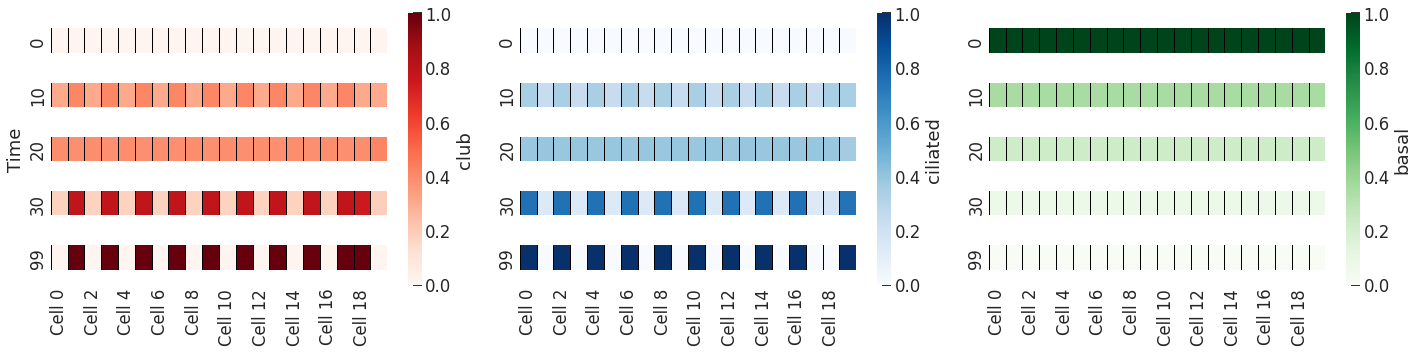

In [8]:
cmap_dict = {'ciliated': 'Blues',
             'club': 'Reds',
             'basal': 'Greens'
            }

time_points = [0, 10, 20, 30, 99]

height = 5
fig = plt.figure(figsize=(4*height, height))

for subplot_index, cell_type in enumerate(attractor_states.columns):
    order_params = []

    for cell in cell_list:
        order_params.append(cell.state_record.loc[time_points, cell_type])

    order_params = pd.concat(order_params, axis=1)
    order_params.columns = ["Cell {}".format(number) for number in range(n_cells)]
    
    ax = fig.add_subplot(1, 3, subplot_index+1)
#     ax.set_title(cell_type)

    sns.heatmap(order_params, linewidths=0.5, linecolor='black', ax=ax, vmin=0, vmax=1, 
                cmap=cmap_dict[cell_type], cbar_kws={'label': cell_type})
    
    if subplot_index == 0:
        ax.set_ylabel('Time')

    for i in range(n_cells):
        ax.axhline(i, color='white', lw=30)
    
# print(pathway)
plt.tight_layout()
# plt.savefig("/project/biophys/scTOP analyses/Mouse airway epithelium/spatial patterns - triple cusp .png", bbox_inches = "tight")
plt.show()

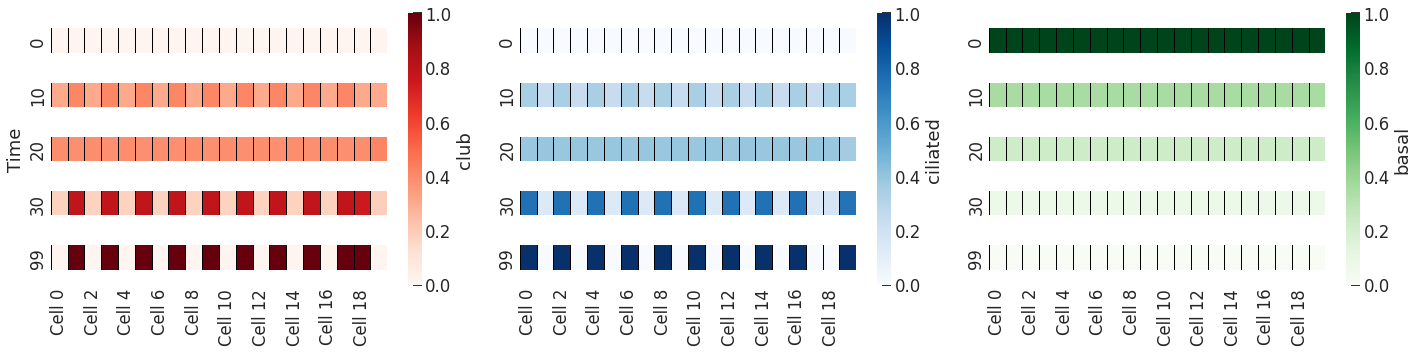

In [23]:
cmap_dict = {'ciliated': 'Blues',
             'club': 'Reds',
             'basal': 'Greens'
            }

time_points = [0, 10, 20, 30, 99]

height = 5
fig = plt.figure(figsize=(4*height, height))

for subplot_index, cell_type in enumerate(attractor_states.columns):
    order_params = []

    for cell in cell_list:
        order_params.append(cell.state_record.loc[time_points, cell_type])

    order_params = pd.concat(order_params, axis=1)
    order_params.columns = ["Cell {}".format(number) for number in range(n_cells)]
    
    ax = fig.add_subplot(1, 3, subplot_index+1)
#     ax.set_title(cell_type)

    sns.heatmap(order_params, linewidths=0.5, linecolor='black', ax=ax, vmin=0, vmax=1, 
                cmap=cmap_dict[cell_type], cbar_kws={'label': cell_type})
    
    if subplot_index == 0:
        ax.set_ylabel('Time')

    for i in range(n_cells):
        ax.axhline(i, color='white', lw=30)
    
# print(pathway)
plt.tight_layout()
# plt.savefig("/project/biophys/scTOP analyses/Mouse airway epithelium/spatial patterns - triple cusp .png", bbox_inches = "tight")
plt.show()

^^^ Lower sigmoid temp

In [28]:
# Simulate many trials and see how many end up in each fate

def simulate_cells(n_cells, total_time, landscape_args, dynamics_args, multicellular_args):
    cell_list = []

    for i in range(n_cells):
        # generate new initial coordinates for each 
        dynamics_args['initial_state'] =  attractor_states['basal'] + rng.normal(size=N, loc=0, scale=multicellular_args['std_dev'])

        attractor_network = AttractorNetwork(dynamics_args, landscape_args)
        cell = Cell(attractor_network, i)

        cell.position = i    
        cell_list.append(cell)

    t = 0
    time_interval = 1 # in minutes        
    while t < total_time:
        for cell in cell_list:

            if cell.position == 0:
                neighbors = cell_list[cell.position + 1].attractor_network.state
            elif cell.position == len(cell_list) - 1:
                neighors = cell_list[cell.position - 1].attractor_network.state
            else:
                neighbors = pd.concat([cell_list[cell.position - 1].attractor_network.state,
                                 cell_list[cell.position + 1].attractor_network.state], axis=1)

            # Signal threshold
            threshold = attractor_states.loc[notch_ligands].mean()[['ciliated', 'club']].mean()

            # Check how the signal compares to the fates' Notch expression
            # Then adjust the signalling parameters according to a sigmoid
            signal_decision = threshold - neighbors.loc[notch_ligands].mean().mean()
            cell.attractor_network.params['f'] = sigmoid(signal_decision, multicellular_args['amp'], multicellular_args['a'])

            cell.attractor_network.update()
            
        t += time_interval
        
    order_param_list = []

    for cell in cell_list:
        magnetizations = pd.DataFrame((1/N)*cell.attractor_network.attractors.dot(cell.attractor_network.state.T))
        order_params = cell.attractor_network.inv_corr.dot(magnetizations)
        order_param_list += [pd.DataFrame(order_params, index = magnetizations.index).T]

    return pd.concat(order_param_list)

n_trials = 10
output_list = []
gene_list = []
signature_list = []
rng = np.random.default_rng()

total_time = 100

landscape_args = {'start_params': {'f': 0, 'k': 0.3},
                  'attractor_coords': [[0, triple_cusp_coords['y0']], [triple_cusp_coords['x1'], triple_cusp_coords['y1']]],
                  'gradients': triple_cusp_grad,
                 }

dynamics_args = {'stored_states': attractor_states.T,
                 'rhos': [0.0, 10]
                }

multicellular_args = {'std_dev': 5,
                      'amp': 0.5,
                      'a': 60
                     }

n_cells = 20

final_order_params = []

for i in trange(n_trials):
    final_order_params += [simulate_cells(n_cells, total_time, landscape_args, dynamics_args, multicellular_args)]

100%|██████████| 10/10 [02:05<00:00, 12.52s/it]


In [29]:
percentages = (np.array(final_order_params)>0.5).sum(axis=1)/n_cells

pd.DataFrame(percentages.mean(axis=0), index=attractor_states.columns).T

,club,ciliated,basal
0,0.425,0.575,0.0


In [48]:
test = pd.DataFrame([0, 1, 2], index=['1', '2', '3']).T
test

,1,2,3
0,0,1,2


In [52]:
test1 = pd.concat([test, pd.DataFrame(['a', 'b'], index=['p1', 'p2']).T], axis=1)
test2 = pd.concat([test, pd.DataFrame(['c', 'd'], index=['p1', 'p2']).T], axis=1)

pd.concat([test1, test2])

,1,2,3,p1,p2
0,0,1,2,a,b
0,0,1,2,c,d


In [30]:
average_scores = []

for cell_type in attractor_states.columns:
    average_scores += [pd.concat(final_order_params, axis=1)[cell_type].mean(axis=1)]

averages = pd.concat(average_scores,axis=1)
averages.columns=attractor_states.columns

averages

,club,ciliated,basal
0,0.400020,0.599945,0.000035
0,0.403245,0.596724,0.000031
0,0.500368,0.499605,0.000027
0,0.599984,0.399989,0.000027
0,0.601339,0.398635,0.000026
0,0.699982,0.299991,0.000027
0,0.601342,0.398632,0.000026
0,0.503240,0.496730,0.000031
0,0.121561,0.878403,0.000036
0,0.201289,0.798675,0.000037


In [28]:
rng = np.random.default_rng()

total_time = 100

landscape_args = {'start_params': {'f': 0, 'k': 0, 'c': 4},
                  'attractor_coords': [[0, double_cusp_coords['y0']], [double_cusp_coords['x1'], double_cusp_coords['y1']]],
                  'gradients': double_cusp_grad,
                 }

dynamics_args = {'stored_states': attractor_states.T,
                 'rhos': [0, 10]
                }

# 1d chain of cells 
n_cells = 20
cell_list = []

for i in range(n_cells):
    # generate new initial coordinates for each 
    dynamics_args['initial_state'] =  attractor_states['basal'] #+ 5*rng.standard_normal(size=N)

    attractor_network = AttractorNetwork(dynamics_args, landscape_args)
    cell = Cell(attractor_network, i)
    
    gene_dict = {}
    for gene in notch_ligands:
        gene_dict[gene] = []
    gene_dict['f'] = []
    
    cell.position = i    
    cell.gene_record = gene_dict
    cell_list.append(cell)

t = 0
time_interval = 1 # in minutes        
for t in trange(total_time):
    for i, cell in enumerate(cell_list):

        if i == 0:
            neighbors = pd.DataFrame(cell_list[i + 1].attractor_network.state)
            neighbor_info = np.array([0.])
        elif i == len(cell_list) - 1:
            neighors = pd.DataFrame(cell_list[i - 1].attractor_network.state)
            neighbor_info = np.array([0.])
        else:
            neighbors = pd.concat([cell_list[i - 1].attractor_network.state,
                             cell_list[i + 1].attractor_network.state], axis=1)
            neighbor_info = np.array([0., 0.])
        
        for i, this_neighbor_info in enumerate(neighbor_info):
            magnetizations = (1/N)*cell.attractor_network.attractors.dot(neighbors.iloc[:, i].T)
            order_params = cell.attractor_network.inv_corr.dot(magnetizations.T)
            
            # order_params[0]: club, order_params[1]: ciliated
            # calculate if this cell is receiving a positive notch signal, i.e. push to become club
            neighbor_info[i] = order_params[1] - order_params[0]
                
        signaling_decision = np.max(neighbor_info)

        cell.attractor_network.params['f'] = - sigmoid(signaling_decision, 1, 1) # 1, 0.5
        
        cell.state_record += [(1/N)*cell.attractor_network.attractors.dot(cell.attractor_network.state.T)]

        for gene in notch_ligands:
            cell.gene_record[gene].append([cell.attractor_network.state.loc[gene]])
            
        cell.gene_record['f'].append(cell.attractor_network.params['f'])
        

        cell.attractor_network.update()
    
for cell in cell_list:
    magnetizations = pd.DataFrame(cell.state_record)
    order_params = cell.attractor_network.inv_corr.dot(magnetizations.T)
    cell.state_record = pd.DataFrame(order_params, index = magnetizations.columns).T
    cell.gene_record = pd.DataFrame(cell.gene_record)

# magnetizations = pd.DataFrame(magnetizations)
# order_params = cell.attractor_network.inv_corr.dot(magnetizations.T)
# output_df = pd.concat([pd.DataFrame(order_params, index = magnetizations.columns).T, magnetizations, pd.DataFrame(gene_dict)], axis=1)

100%|██████████| 100/100 [00:15<00:00,  6.45it/s]


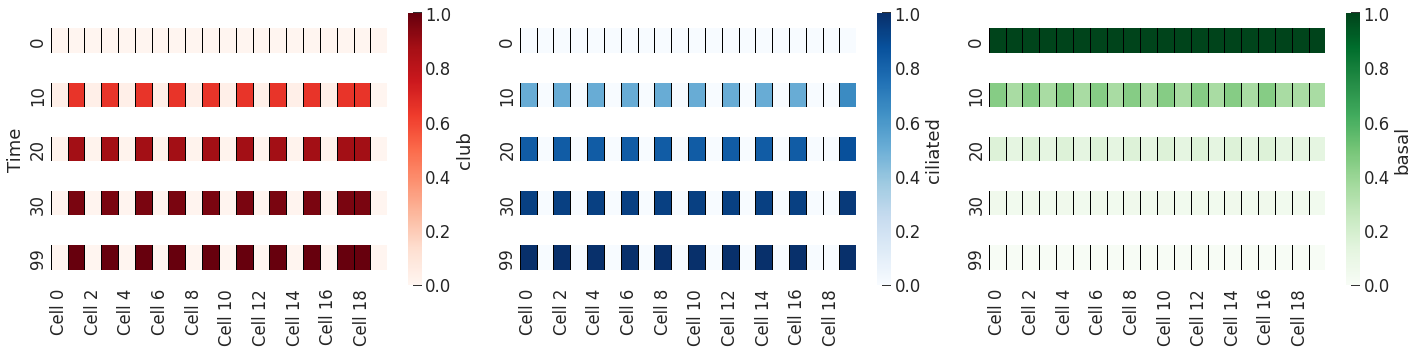

In [29]:
cmap_dict = {'ciliated': 'Blues',
             'club': 'Reds',
             'basal': 'Greens'
            }

time_points = [0, 10, 20, 30, 99]

height = 5
fig = plt.figure(figsize=(4*height, height))

for subplot_index, cell_type in enumerate(attractor_states.columns):
    order_params = []

    for cell in cell_list:
        order_params.append(cell.state_record.loc[time_points, cell_type])

    order_params = pd.concat(order_params, axis=1)
    order_params.columns = ["Cell {}".format(number) for number in range(n_cells)]
    
    ax = fig.add_subplot(1, 3, subplot_index+1)
#     ax.set_title(cell_type)

    sns.heatmap(order_params, linewidths=0.5, linecolor='black', ax=ax, vmin=0, vmax=1, 
                cmap=cmap_dict[cell_type], cbar_kws={'label': cell_type})
    
    if subplot_index == 0:
        ax.set_ylabel('Time')

    for i in range(n_cells):
        ax.axhline(i, color='white', lw=30)
    

plt.tight_layout()
# plt.savefig("/project/biophys/scTOP analyses/Mouse airway epithelium/spatial patterns dual cusp.png", bbox_inches = "tight")
plt.show()

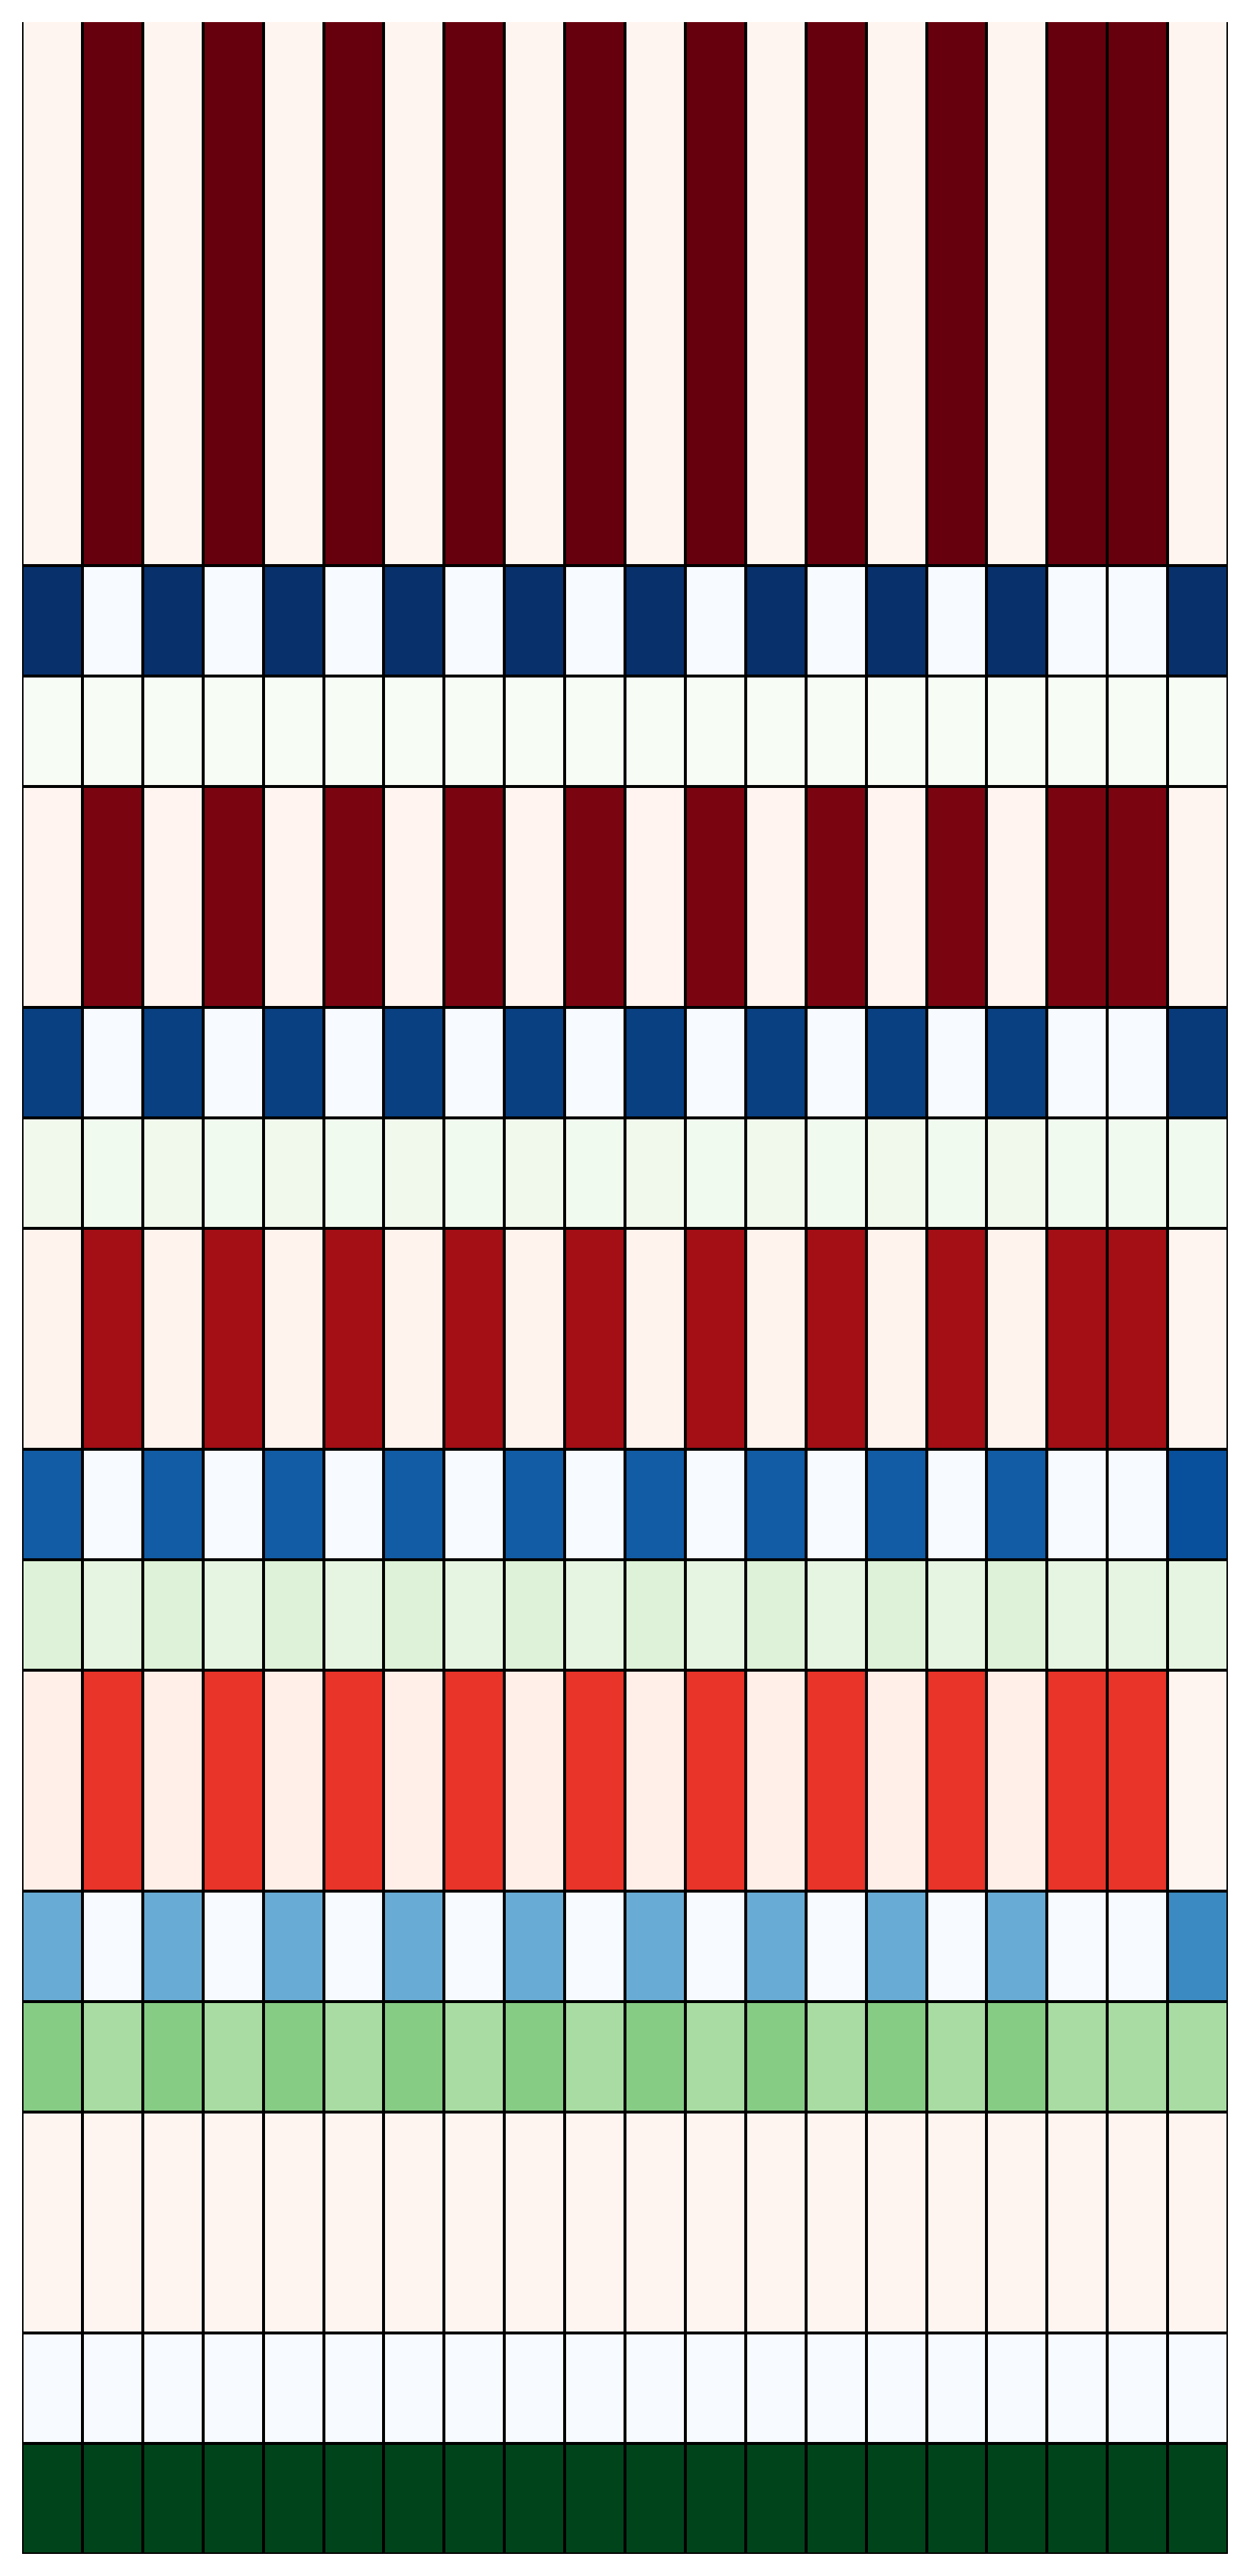

In [32]:
cmap_dict = {'ciliated': 'Blues',
             'club': 'Reds',
             'basal': 'Greens'
            }

time_points = [0, 10, 20, 30, 99]

width = 6
fig = plt.figure(figsize=(width, 2*width))

order_params_dict = {}

for subplot_index, cell_type in enumerate(attractor_states.columns):
    order_params = []

    for cell in cell_list:
        order_params.append(cell.state_record.loc[time_points, cell_type])

    order_params = pd.concat(order_params, axis=1)
    order_params.columns = ["Cell {}".format(number) for number in range(n_cells)]
    order_params_dict[cell_type] = order_params
    
#     ax = fig.add_subplot(1, 3, subplot_index+1)
#     ax.set_title(cell_type)

heatmap_position = 0
spacing = 150

for hmap_index, time_point in enumerate(time_points):
    for cell_type in attractor_states.columns[::-1]:
        sns.heatmap([order_params_dict[cell_type].iloc[hmap_index]], linewidths=0.5, linecolor='black', vmin=0, vmax=1, 
                cmap=cmap_dict[cell_type], cbar_kws={'label': cell_type}, offsets=(0, heatmap_position), cbar=None)
        heatmap_position += spacing
    heatmap_position += spacing
    
    
#     if subplot_index == 0:
#         ax.set_ylabel('Time')
# ax = plt.gca()
# for i in range(len(time_points)):
#     ax.axhline(i, color='white', lw=20)
plt.axis("off")


plt.tight_layout()
plt.savefig("/project/biophys/scTOP analyses/Mouse airway epithelium/spatial patterns dual cusp.png", bbox_inches = "tight")
plt.show()

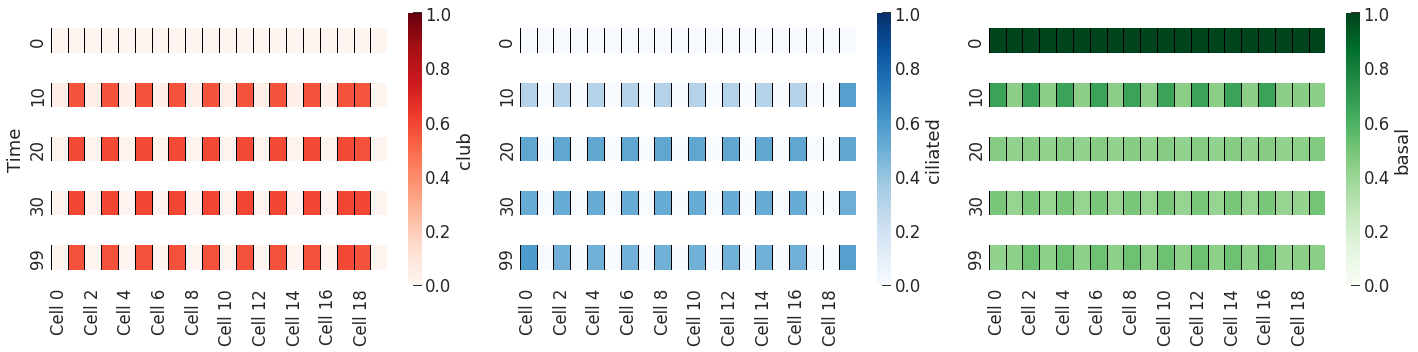

In [21]:
cmap_dict = {'ciliated': 'Blues',
             'club': 'Reds',
             'basal': 'Greens'
            }

time_points = [0, 10, 20, 30, 99]

height = 5
fig = plt.figure(figsize=(4*height, height))

for subplot_index, cell_type in enumerate(attractor_states.columns):
    order_params = []

    for cell in cell_list:
        order_params.append(cell.state_record.loc[time_points, cell_type])

    order_params = pd.concat(order_params, axis=1)
    order_params.columns = ["Cell {}".format(number) for number in range(n_cells)]
    
    ax = fig.add_subplot(1, 3, subplot_index+1)
#     ax.set_title(cell_type)

    sns.heatmap(order_params, linewidths=0.5, linecolor='black', ax=ax, vmin=0, vmax=1, 
                cmap=cmap_dict[cell_type], cbar_kws={'label': cell_type})
    
    if subplot_index == 0:
        ax.set_ylabel('Time')

    for i in range(n_cells):
        ax.axhline(i, color='white', lw=30)
    

plt.tight_layout()
# plt.savefig("/project/biophys/scTOP analyses/Mouse airway epithelium/spatial patterns dual cusp.png", bbox_inches = "tight")
plt.show()

In [31]:
# Simulate many trials and see how many end up in each fate

n_trials = 10
output_list = []
gene_list = []
signature_list = []
rng = np.random.default_rng()

total_time = 50

landscape_args = {'start_params': {'f': 0, 'k': 0.15},
                  'attractor_coords': [[0, double_cusp_coords['y0']], [double_cusp_coords['x1'], double_cusp_coords['y1']]],
                  'gradients': double_cusp_grad,
                 }

dynamics_args = {'stored_states': attractor_states.T,
                 'rhos': [0, 10]
                }

multicellular_args = {'std_dev': 5,
                      'amp': 1,
                      'a': 30
                     }

n_cells = 20

final_order_params = []

for i in trange(n_trials):
    final_order_params += [simulate_cells(n_cells, total_time, landscape_args, dynamics_args, multicellular_args)]

100%|██████████| 10/10 [01:03<00:00,  6.37s/it]


In [32]:
percentages = (np.array(final_order_params)>0.5).sum(axis=1)/n_cells

pd.DataFrame(percentages.mean(axis=0), index=attractor_states.columns).T

,club,ciliated,basal
0,0.39,0.61,0.0


In [33]:
average_scores = []

for cell_type in attractor_states.columns:
    average_scores += [pd.concat(final_order_params, axis=1)[cell_type].mean(axis=1)]

averages = pd.concat(average_scores,axis=1)
averages.columns=attractor_states.columns

averages

,club,ciliated,basal
0,0.540559,0.378482,0.080954
0,0.295295,0.652256,0.052455
0,0.466429,0.485987,0.047578
0,0.388190,0.579476,0.032328
0,0.373342,0.559181,0.067610
0,0.448671,0.491169,0.060181
0,0.384502,0.584803,0.030609
0,0.366173,0.586540,0.047294
0,0.185392,0.756698,0.057995
0,0.432785,0.487238,0.079846
